In [1]:
!nvidia-smi

Fri Sep 11 00:59:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# AI Image Generator with Multilingual Support

**Generate stunning images from text descriptions in any language!**

## Key Features
- **Multilingual Support**: Automatic translation of any language to English
- **Free GPU**: Uses Google Colab's free GPU acceleration
- **Advanced Controls**: Adjustable inference steps, guidance scale, and image dimensions
- **Multiple Prompts**: Support for positive and negative prompts

## Setup Instructions
1. This notebook **requires GPU acceleration**
2. Go to `Runtime` → `Change runtime type` → Select `T4 GPU` or better
3. Run cells from top to bottom

## How It Works
Your input → Automatic Translation to English → Image Generation using Stable Diffusion XL → Display Result

## Configuration Constants

All important settings and model configurations are defined below for easy customization.

In [2]:
# ============================================================================
# Configuration Constants
# ============================================================================

# Model configurations
TRANSLATION_MODEL = "facebook/m2m100_418M"
IMAGE_GENERATION_MODEL = "Lykon/dreamshaper-xl-lightning"
TARGET_LANGUAGE = "en"

# Generation parameter ranges
INFERENCE_STEPS_MIN = 1
INFERENCE_STEPS_MAX = 50
INFERENCE_STEPS_DEFAULT = 25
GUIDANCE_SCALE_MIN = 1.0
GUIDANCE_SCALE_MAX = 15.0
GUIDANCE_SCALE_DEFAULT = 7.5
IMAGE_SIZES = [512, 768, 1024]
DEFAULT_IMAGE_SIZE = 768

# Translation settings
MAX_TRANSLATION_TOKENS = 128

# Logging
VERBOSE = True  # Set to False to reduce console output

## STEP 1: Install Required Libraries

Install all dependencies needed for image generation and translation. This may take 1-2 minutes on first run.

In [3]:
# Install required packages (silently)
# - diffusers: Hugging Face diffusion models pipeline
# - transformers: Pre-trained transformer models for translation
# - torch, torchvision: PyTorch deep learning framework
# - accelerate: Distributed training utilities
# - safetensors: Safe model serialization format
# - gradio: Optional - for web UI in production

print("Installing required packages...")
!pip install --quiet diffusers transformers torch torchvision accelerate safetensors
print("All packages installed successfully!")

Installing required packages...
All packages installed successfully!


## STEP 2: Authenticate with Hugging Face (Optional)

Login to Hugging Face Hub to access gated models. This step is recommended but optional.

In [4]:
# Step 1: Import required authentication libraries
from huggingface_hub import login
from google.colab import userdata

# Step 2: Retrieve HF token from Colab Secrets
# To add your HF_TOKEN:
# 1. Go to https://huggingface.co/settings/tokens
# 2. Create or copy your token
# 3. In Colab, click Secrets in the left sidebar
# 4. Add a new secret: name="HF_TOKEN", value=<your_token>

try:
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        login(hf_token, add_to_git_credential=True)
        print("Successfully logged in to Hugging Face Hub")
    else:
        print("HF_TOKEN not found - proceeding without authentication")
        print("Note: Some models may have access restrictions")
except Exception as e:
    print(f"Authentication skipped: {str(e)}")
    print("Note: You can continue, but some models may require login")

Authentication skipped: Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.
Note: You can continue, but some models may require login


## STEP 3: Import Libraries and Check GPU

Import all required Python libraries and verify GPU availability.

In [5]:
# Import core libraries for image generation and translation
import torch
from diffusers import StableDiffusionXLPipeline
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

# Import translation libraries
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer

# ============================================================================
# GPU Detection and Information
# ============================================================================

print("=" * 60)
print("GPU INFORMATION")
print("=" * 60)

# Check GPU availability
gpu_available = torch.cuda.is_available()
print(f"GPU Available: {gpu_available}")

if gpu_available:
    device_name = torch.cuda.get_device_name(0)
    device_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
    print(f"GPU Name: {device_name}")
    print(f"GPU Memory: {device_memory:.1f} GB")
    device = "cuda"
else:
    print("No GPU detected - Using CPU (slower)")
    device = "cpu"

print("=" * 60)

GPU INFORMATION
GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.6 GB


In [6]:
# ============================================================================
# STEP 4: Define Translation Function
# ============================================================================

def translate_to_english(text: str) -> str:
    """
    Automatically translate any language input to English using M2M100 model.
    
    Supports 100+ languages with automatic language detection.
    Falls back to returning original text if translation fails.
    
    Args:
        text (str): Input text in any language
        
    Returns:
        str: Translated text in English, or original text if empty/error
    """
    
    # Skip translation for empty strings
    if not text or not text.strip():
        return text
    
    if VERBOSE:
        print(f"[Translation] Processing: '{text[:60]}...'")
    
    try:
        # Step 1: Load tokenizer for the translation model
        tokenizer = M2M100Tokenizer.from_pretrained(TRANSLATION_MODEL)
        
        # Step 2: Load the M2M100 model with GPU optimization if available
        if torch.cuda.is_available():
            model = M2M100ForConditionalGeneration.from_pretrained(
                TRANSLATION_MODEL,
                torch_dtype=torch.float16
            ).to("cuda")
        else:
            model = M2M100ForConditionalGeneration.from_pretrained(TRANSLATION_MODEL)
        
        # Step 3: Tokenize input text
        inputs = tokenizer(text, return_tensors="pt")
        
        # Step 4: Move inputs to GPU if available
        if torch.cuda.is_available():
            inputs = {k: v.to("cuda") for k, v in inputs.items()}
        
        # Step 5: Set target language to English
        target_lang_id = tokenizer.get_lang_id(TARGET_LANGUAGE)
        
        # Step 6: Generate translation
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                forced_bos_token_id=target_lang_id,
                max_new_tokens=MAX_TRANSLATION_TOKENS
            )
        
        # Step 7: Decode and return translated text
        translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        if VERBOSE:
            print(f"[Translation] Result: '{translated_text}'")
        
        return translated_text
        
    except Exception as e:
        # Log error and return original text as fallback
        print(f"[Warning] Translation failed: {str(e)}")
        print(f"[Fallback] Using original text: '{text}'")
        return text

## STEP 5: Load Image Generation Model

Load the Stable Diffusion XL model for high-quality image generation. This may take 2-3 minutes on first run.

In [7]:
# ============================================================================
# Load Stable Diffusion XL Model
# ============================================================================

print("=" * 60)
print("LOADING IMAGE GENERATION MODEL")
print("=" * 60)
print(f"Model: {IMAGE_GENERATION_MODEL}")
print(f"Device: {device}")
print("This may take 2-3 minutes on first run...")
print("=" * 60)

try:
    # Load pre-trained Stable Diffusion XL model
    pipe = StableDiffusionXLPipeline.from_pretrained(
        IMAGE_GENERATION_MODEL,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        safety_checker=None,  # Disable safety checker for faster inference
    )
    
    # Move pipeline to device
    pipe = pipe.to(device)
    
    # Optimization: Enable attention slicing to reduce memory usage
    if device == "cuda":
        pipe.enable_attention_slicing()
    
    print("Model loaded successfully!")
    print(f"Using device: {device}")
    print("=" * 60)
    
except Exception as e:
    print(f"Error loading model: {str(e)}")
    print("Please check your GPU availability and retry")
    raise

LOADING IMAGE GENERATION MODEL
Model: Lykon/dreamshaper-xl-lightning
Device: cuda
This may take 2-3 minutes on first run...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model_index.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Keyword arguments {'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully!
Using device: cuda


## STEP 6: Define Image Generation Helper Function

Create a reusable function to generate and display images with any language input.

In [8]:
def generate_and_display_image(
    prompt: str,
    negative_prompt: str = "",
    steps: int = INFERENCE_STEPS_DEFAULT,
    guidance_scale: float = GUIDANCE_SCALE_DEFAULT,
    width: int = DEFAULT_IMAGE_SIZE,
    height: int = DEFAULT_IMAGE_SIZE,
    seed: int = -1,
    save_path: str = None
):
    """
    Generate an image from text prompt and display it.
    
    Automatically translates non-English prompts to English before generation.
    
    Args:
        prompt (str): Positive prompt in any language
        negative_prompt (str): Negative prompt (features to avoid)
        steps (int): Number of inference steps (higher = better quality but slower)
        guidance_scale (float): CFG scale for guidance strength
        width (int): Image width in pixels
        height (int): Image height in pixels
        seed (int): Random seed (-1 for random)
        save_path (str): Path to save image (optional)
        
    Returns:
        PIL.Image: Generated image
    """
    
    print("=" * 60)
    print("IMAGE GENERATION PROCESS")
    print("=" * 60)
    
    # Step 1: Translate prompts to English
    print("[1/4] Translating prompts to English...")
    translated_prompt = translate_to_english(prompt)
    translated_negative = translate_to_english(negative_prompt) if negative_prompt.strip() else ""
    
    # Step 2: Set up random seed
    print("[2/4] Setting up generation parameters...")
    if seed >= 0:
        generator = torch.Generator(device=device).manual_seed(int(seed))
    else:
        generator = None
    
    # Step 3: Generate image
    print(f"[3/4] Generating image ({steps} steps, guidance_scale={guidance_scale})...")
    output = pipe(
        prompt=translated_prompt,
        negative_prompt=translated_negative,
        num_inference_steps=int(steps),
        guidance_scale=float(guidance_scale),
        height=int(height),
        width=int(width),
        generator=generator
    )
    image = output.images[0]
    
    # Step 4: Display and save image
    print("[4/4] Displaying result...")
    
    # Display with matplotlib
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)
    ax.axis('off')
    
    # Add title with original prompt
    title = f"Prompt: {prompt}\n"
    if negative_prompt:
        title += f"Negative: {negative_prompt}"
    ax.set_title(title, fontsize=11, wrap=True, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Save image if path provided
    if save_path:
        image.save(save_path)
        print(f"Image saved to: {save_path}")
    
    print("=" * 60)
    print("Generation completed!")
    print("=" * 60)
    
    return image

## STEP 7: Three examples


IMAGE GENERATION PROCESS
[1/4] Translating prompts to English...
[Translation] Processing: 'A majestic white wolf with glowing crystal blue eyes, standi...'


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 2.42MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Translation] Result: 'A majestic white wolf with glowing crystal blue eyes, standing on a snowy mountain peak at night, hyperreal, 8k resolution, mystical atmosphere'
[2/4] Setting up generation parameters...
[3/4] Generating image (25 steps, guidance_scale=7.5)...


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


[4/4] Displaying result...


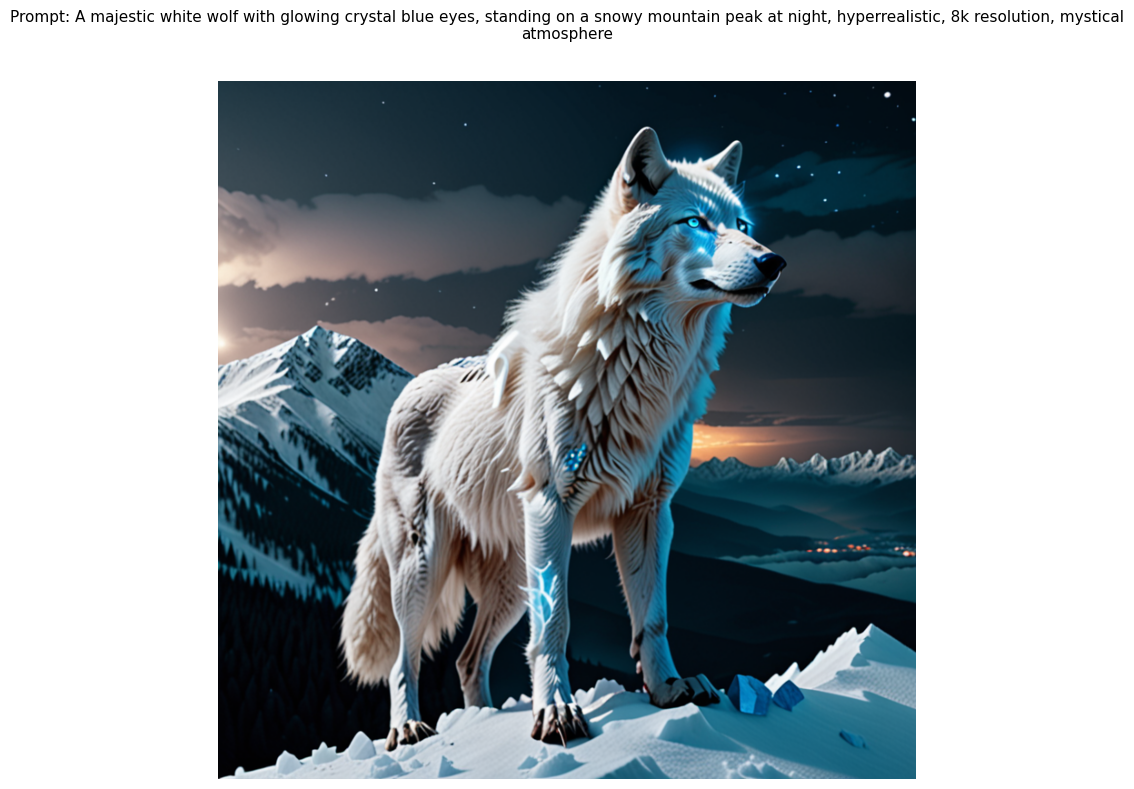

Image saved to: generated_image_english.png
Generation completed!


In [9]:
# Example 1: English Prompt
prompt_en = "A majestic white wolf with glowing crystal blue eyes, standing on a snowy mountain peak at night, hyperrealistic, 8k resolution, mystical atmosphere"

# Generate image
image_1 = generate_and_display_image(
    prompt=prompt_en,
    steps=25,
    guidance_scale=7.5,
    save_path="generated_image_english.png"
)

IMAGE GENERATION PROCESS
[1/4] Translating prompts to English...
[Translation] Processing: 'Một con mèo phi hành gia đang ôm mặt trăng, phong cách hoạt ...'


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Translation] Result: 'A cat astronaut is hugging the moon, style animation 3D cute'
[2/4] Setting up generation parameters...
[3/4] Generating image (25 steps, guidance_scale=7.5)...


  0%|          | 0/25 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


[4/4] Displaying result...


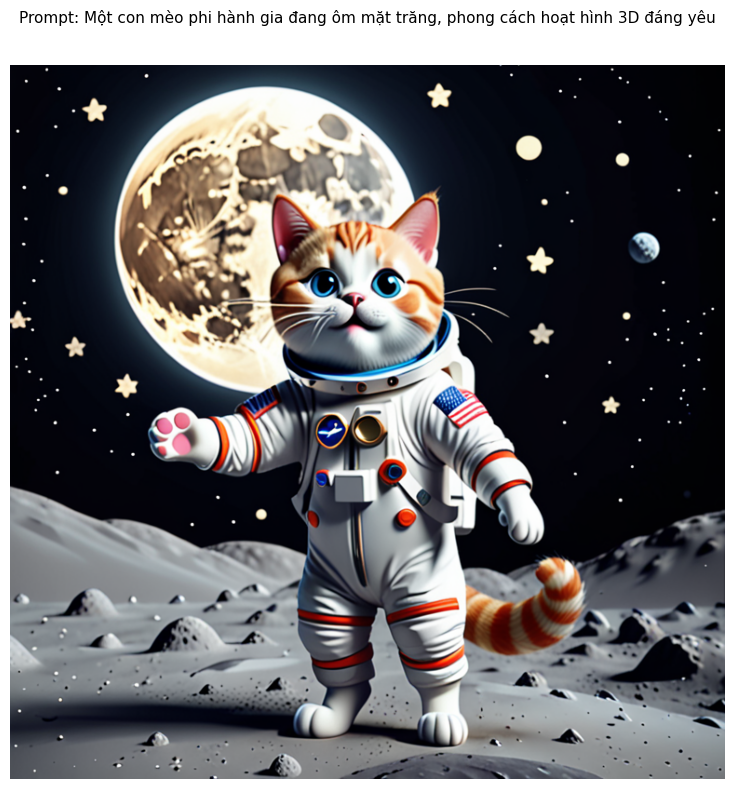

Image saved to: generated_image_vietnamese.png
Generation completed!


In [10]:
# Example 2: Vietnamese Prompt
prompt_vi = "Một con mèo phi hành gia đang ôm mặt trăng, phong cách hoạt hình 3D đáng yêu"

# Generate image (will be automatically translated to English)
image_2 = generate_and_display_image(
    prompt=prompt_vi,
    steps=25,
    guidance_scale=7.5,
    save_path="generated_image_vietnamese.png"
)

IMAGE GENERATION PROCESS
[1/4] Translating prompts to English...
[Translation] Processing: 'サイバーパンクの夜の街、ネオンライト、高いビル、アニメスタイル...'


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Translation] Result: 'Cyberpunk’s Night Street, Neonlight, High Building, Anime Style'
[2/4] Setting up generation parameters...
[3/4] Generating image (25 steps, guidance_scale=7.5)...


  0%|          | 0/25 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


[4/4] Displaying result...


/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12496 (\N{KATAKANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2138/3191590558.py:73: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  

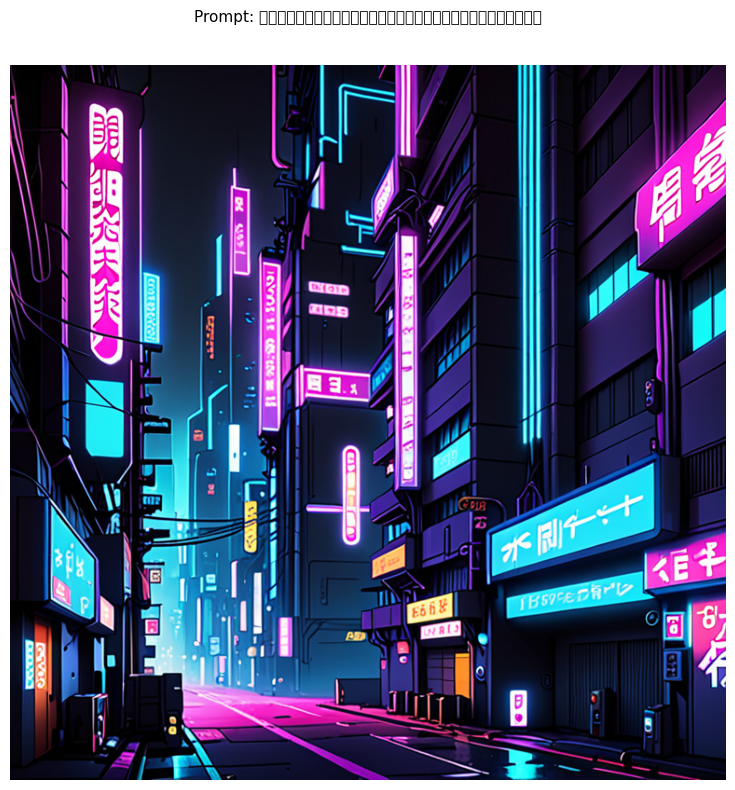

Image saved to: generated_image_japanese.png
Generation completed!


In [11]:
# Example 3: Japanese Prompt
prompt_ja = "サイバーパンクの夜の街、ネオンライト、高いビル、アニメスタイル"

# Generate image (will be automatically translated to English)
image_3 = generate_and_display_image(
    prompt=prompt_ja,
    steps=25,
    guidance_scale=7.5,
    save_path="generated_image_japanese.png"
)

## STEP 8: Custom Image Generation

Modify the parameters below to create your own custom images!

Custom Image Generation
Prompt: A futuristic cyberpunk city at night, neon lights, tall skyscrapers, flying cars, hyperrealistic
Negative: blurry, low quality, deformed, ugly
Steps: 30, Guidance: 8.5
IMAGE GENERATION PROCESS
[1/4] Translating prompts to English...
[Translation] Processing: 'A futuristic cyberpunk city at night, neon lights, tall skys...'


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Translation] Result: 'A futuristic cyberpunk city at night, neon lights, high skyscrapers, flying cars, hyperrealistic'
[Translation] Processing: 'blurry, low quality, deformed, ugly...'


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Translation] Result: 'blurry, low quality, deformed, ugly'
[2/4] Setting up generation parameters...
[3/4] Generating image (30 steps, guidance_scale=8.5)...


  0%|          | 0/30 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


[4/4] Displaying result...


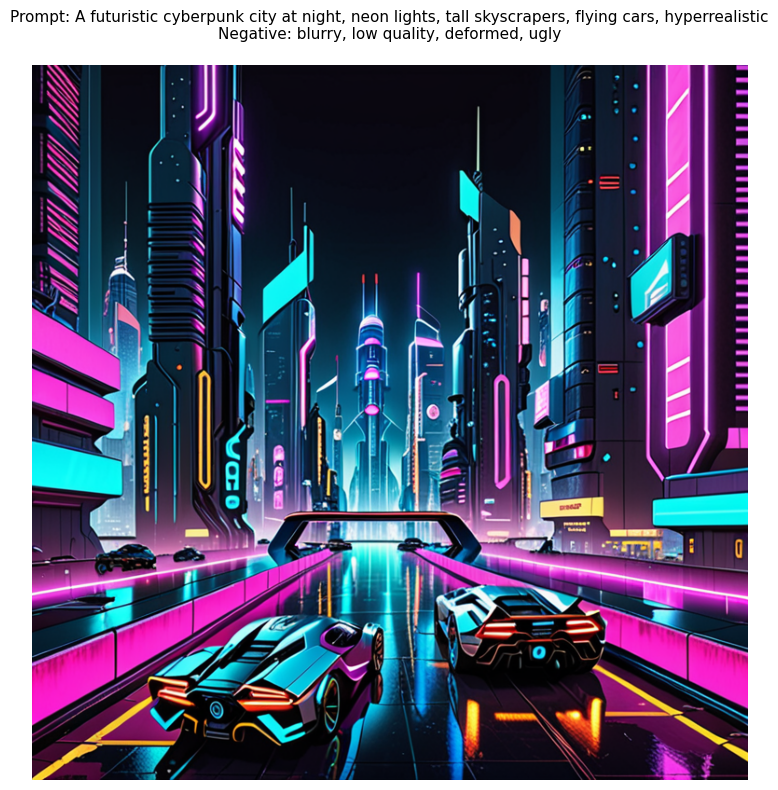

Image saved to: generated_image_custom.png
Generation completed!


In [12]:
# ============================================================================
# CUSTOMIZE THESE PARAMETERS FOR YOUR OWN IMAGE!
# ============================================================================

# Positive prompt - describe what you want to see
custom_prompt = "A futuristic cyberpunk city at night, neon lights, tall skyscrapers, flying cars, hyperrealistic"

# Negative prompt - describe what you want to avoid (optional)
custom_negative = "blurry, low quality, deformed, ugly"

# Generation parameters (experiment with these!)
custom_steps = 30  # 20-50 recommended (higher = better quality but slower)
custom_guidance = 8.5  # 7-15 recommended (higher = more adherence to prompt)
custom_width = 768  # 512, 768, or 1024
custom_height = 768  # 512, 768, or 1024
custom_seed = -1  # -1 for random, or use a fixed number for reproducible results

print("Custom Image Generation")
print("=" * 60)
print(f"Prompt: {custom_prompt}")
print(f"Negative: {custom_negative}")
print(f"Steps: {custom_steps}, Guidance: {custom_guidance}")
print("=" * 60)

# Generate the image
image_custom = generate_and_display_image(
    prompt=custom_prompt,
    negative_prompt=custom_negative,
    steps=custom_steps,
    guidance_scale=custom_guidance,
    width=custom_width,
    height=custom_height,
    seed=custom_seed,
    save_path="generated_image_custom.png"
)